# Parameter Identification with PINNs

This notebook flips the direction of the core path so far.

Notebooks `01`-`06` all solved *forward* problems: the PDE and its parameters were known, and we asked the network to recover the solution. Now we keep the same machinery but invert it. We observe the solution at a handful of space-time points and ask a PINN to recover a single unknown PDE parameter jointly with the solution field.


## Notebook Contract

- **Status:** core-executable
- **Research question:** From a few noisy space-time observations of a heat equation, can a PINN jointly recover the field and the unknown diffusion coefficient $\alpha$?
- **Canonical problem:** 1D heat equation $u_t=\alpha\, u_{xx}$ with homogeneous Dirichlet boundary conditions and a known sinusoidal initial condition
- **Main comparison:** parameter recovery under clean sensor data vs noisy sensor data, both trained from the same PINN initialization


## Why This Notebook Exists

The inverse-problem version of a PINN is mechanically tiny. We do not change the loss function too much; we just add one learnable scalar $\alpha$ to the optimizer, and we add a *data-fit* term alongside the physics residual.

This notebook is narrow on purpose: one unknown parameter, a simple observable, and a clean comparison between the noise-free regime and a small-noise regime. The same recipe extends immediately to spatially varying parameters and to multiple unknowns, which is the territory of `10_Research_Tracks/05_inverse_and_discovery`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(7)
torch.manual_seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())

print(f"Repo root: {repo_root}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")


Repo root: /home/duncan-nguyen/research/physics-informed-learning
NumPy: 2.4.3
PyTorch: 2.10.0+cu128
Device: cpu


## Canonical Problem

The forward problem is the 1D heat equation on $x\in(0,1)$, $t\in(0,T)$,
$$u_t(x,t)=\alpha\, u_{xx}(x,t), \qquad u(0,t)=u(1,t)=0, \qquad u(x,0)=\sin(\pi x),$$
with the exact solution
$$u^*(x,t)=e^{-\alpha\pi^2 t}\sin(\pi x).$$

We pretend $\alpha$ is unknown to the PINN. The truth is $\alpha^*=0.5$. The PINN learns a scalar $\alpha_\theta$ together with the field $u_\theta(x,t)$.


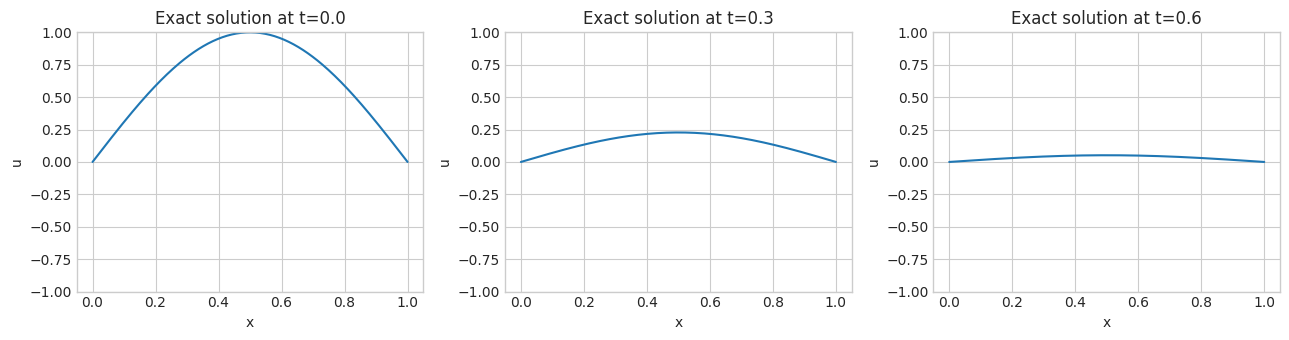

In [2]:
ALPHA_TRUE = 0.5
T_FINAL = 0.6


def exact_solution_np(x, t):
    return np.exp(-ALPHA_TRUE * np.pi ** 2 * t) * np.sin(np.pi * x)


x_plot = np.linspace(0.0, 1.0, 200)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, t in zip(axes, [0.0, 0.3, 0.6]):
    ax.plot(x_plot, exact_solution_np(x_plot, t), label=f"t={t:.1f}")
    ax.set_title(f"Exact solution at t={t:.1f}")
    ax.set_xlabel("x")
    ax.set_ylabel("u")
    ax.set_ylim(-1.0, 1.0)
plt.tight_layout()
plt.show()


## Inverse PINN Formulation

The model represents $u_\theta(x,t)$ and a separate learnable scalar $\alpha_\theta\in\mathbb{R}_{>0}$. We enforce positivity via a softplus transform on a raw parameter $\beta_\theta$,
$$\alpha_\theta = \mathrm{softplus}(\beta_\theta) + 10^{-3}.$$

The objective combines four terms:

- **Physics residual:** on sampled $(x,t)$ interior points, $u_t - \alpha_\theta u_{xx}$,
- **Boundary:** $u(0,t)=u(1,t)=0$,
- **Initial:** $u(x,0)=\sin(\pi x)$,
- **Data fit:** at the sensor points, $|u_\theta(x_i,t_i) - u^{\text{obs}}_i|^2$.

We fix the same weights for clean and noisy runs; the only difference is the data.


In [3]:
def gradient(y, x):
    return torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True, retain_graph=True)[0]


class InversePINN(nn.Module):
    def __init__(self, width=64, depth=2):
        super().__init__()
        layers = [nn.Linear(2, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers.extend([nn.Linear(width, width), nn.Tanh()])
        layers.append(nn.Linear(width, 1))
        self.net = nn.Sequential(*layers)
        self.raw_alpha = nn.Parameter(torch.tensor(0.0, device=device))

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=-1))

    @property
    def alpha(self):
        return torch.nn.functional.softplus(self.raw_alpha) + 1e-3


def inverse_loss(model, x_int, t_int, x_bc, t_bc, x_ic, t_ic, obs, weights):
    u_int = model(x_int, t_int)
    u_t = gradient(u_int, t_int)
    u_x = gradient(u_int, x_int)
    u_xx = gradient(u_x, x_int)
    residual = u_t - model.alpha * u_xx
    physics = torch.mean(residual.square())

    u_bc = model(x_bc, t_bc)
    bc = torch.mean(u_bc.square())

    u_ic = model(x_ic, t_ic)
    ic = torch.mean((u_ic - torch.sin(np.pi * x_ic)).square())

    data = torch.mean((obs["u"] - model(obs["x"], obs["t"])).square())

    total = (
        weights["physics"] * physics
        + weights["boundary"] * bc
        + weights["initial"] * ic
        + weights["data"] * data
    )
    return {"total": total, "physics": physics, "boundary": bc, "initial": ic, "data": data}


## Sensor Observations

We sample `40` sensor pairs $(x_i, t_i)$ uniformly in $[0,1]\times[0,0.6]$. The clean dataset uses the exact solution. The noisy dataset adds i.i.d. Gaussian noise with $\sigma = 0.03\|u\|_{\max}$ to simulate measurement error.


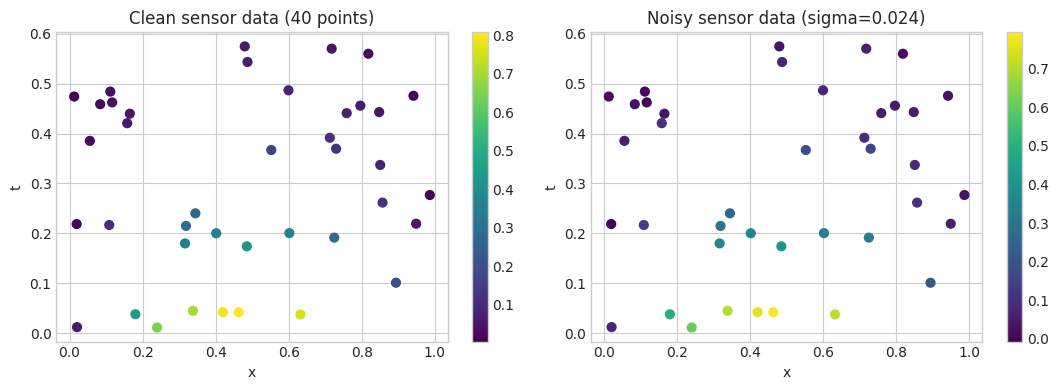

In [4]:
np.random.seed(11)
n_sensors = 40

x_obs_np = np.random.uniform(0.0, 1.0, size=n_sensors)
t_obs_np = np.random.uniform(0.0, T_FINAL, size=n_sensors)
u_clean_np = exact_solution_np(x_obs_np, t_obs_np)
noise_scale = 0.03 * np.max(np.abs(u_clean_np))
noise = noise_scale * np.random.normal(size=n_sensors)
u_noisy_np = u_clean_np + noise

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sc1 = axes[0].scatter(x_obs_np, t_obs_np, c=u_clean_np, cmap="viridis", s=40)
axes[0].set_title("Clean sensor data (40 points)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("t")
plt.colorbar(sc1, ax=axes[0])
sc2 = axes[1].scatter(x_obs_np, t_obs_np, c=u_noisy_np, cmap="viridis", s=40)
axes[1].set_title(f"Noisy sensor data (sigma={noise_scale:.3f})")
axes[1].set_xlabel("x")
axes[1].set_ylabel("t")
plt.colorbar(sc2, ax=axes[1])
plt.tight_layout()
plt.show()


## Training Setup


In [5]:
config = {
    "num_interior": 1024,
    "num_boundary": 64,
    "num_initial": 64,
    "width": 64,
    "depth": 2,
    "learning_rate": 1e-3,
    "steps": 4000,
    "log_every": 200,
    "weights": {"physics": 1.0, "boundary": 5.0, "initial": 5.0, "data": 10.0},
}


def make_interior_points(n):
    x = torch.rand(n, 1, device=device)
    t = torch.rand(n, 1, device=device) * T_FINAL
    return x.clone().detach().requires_grad_(True), t.clone().detach().requires_grad_(True)


def make_bc_points(n):
    t = torch.rand(n // 2, 1, device=device) * T_FINAL
    x_zeros = torch.zeros(n // 2, 1, device=device)
    x_ones = torch.ones(n // 2, 1, device=device)
    x_bc = torch.cat([x_zeros, x_ones], dim=0)
    t_bc = torch.cat([t, t], dim=0)
    return x_bc, t_bc


def make_ic_points(n):
    x = torch.linspace(0.0, 1.0, n, device=device).view(-1, 1)
    t = torch.zeros_like(x)
    return x.clone().detach().requires_grad_(True), t.clone().detach().requires_grad_(True)


def build_obs(x_np, t_np, u_np):
    return {
        "x": torch.tensor(x_np, dtype=torch.float32, device=device).view(-1, 1),
        "t": torch.tensor(t_np, dtype=torch.float32, device=device).view(-1, 1),
        "u": torch.tensor(u_np, dtype=torch.float32, device=device).view(-1, 1),
    }


def train_inverse(u_np):
    torch.manual_seed(7)
    np.random.seed(11)
    model = InversePINN(width=config["width"], depth=config["depth"]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
    x_int, t_int = make_interior_points(config["num_interior"])
    x_bc, t_bc = make_bc_points(config["num_boundary"])
    x_ic, t_ic = make_ic_points(config["num_initial"])
    obs = build_obs(x_obs_np, t_obs_np, u_np)
    history = {"step": [], "alpha": [], "total": []}
    for step in range(config["steps"]):
        opt.zero_grad()
        losses = inverse_loss(
            model, x_int, t_int, x_bc, t_bc, x_ic, t_ic,
            obs=obs, weights=config["weights"],
        )
        losses["total"].backward()
        opt.step()
        if step % config["log_every"] == 0 or step == config["steps"] - 1:
            history["step"].append(step)
            history["alpha"].append(float(model.alpha.item()))
            history["total"].append(float(losses["total"].item()))
    return model, history


clean_model, clean_history = train_inverse(u_clean_np)
noisy_model, noisy_history = train_inverse(u_noisy_np)
print(f"Recovered alpha (clean): {clean_history['alpha'][-1]:.4f}, truth: {ALPHA_TRUE}")
print(f"Recovered alpha (noisy): {noisy_history['alpha'][-1]:.4f}, truth: {ALPHA_TRUE}")


Recovered alpha (clean): 0.4990, truth: 0.5
Recovered alpha (noisy): 0.5013, truth: 0.5


## Results


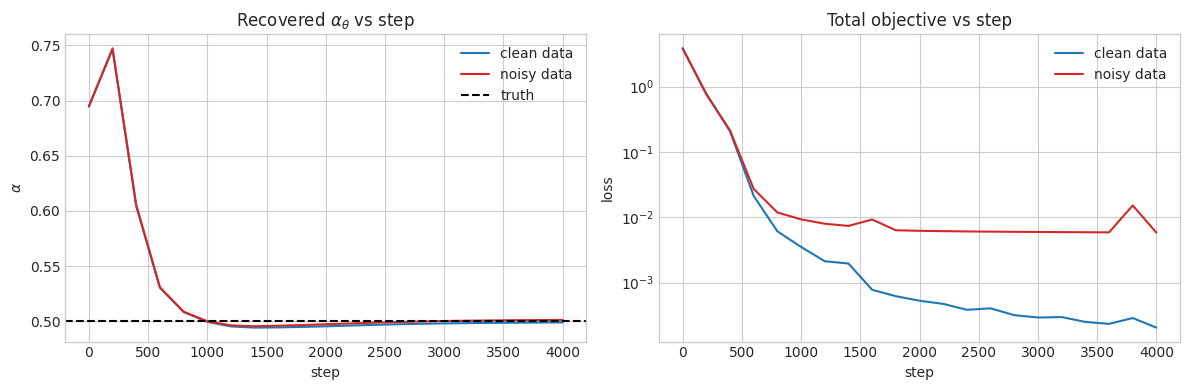

Clean  alpha error: 0.21%
Noisy  alpha error: 0.25%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(clean_history["step"], clean_history["alpha"], color="tab:blue", label="clean data")
axes[0].plot(noisy_history["step"], noisy_history["alpha"], color="tab:red", label="noisy data")
axes[0].axhline(ALPHA_TRUE, color="black", linestyle="--", label="truth")
axes[0].set_title(r"Recovered $\alpha_\theta$ vs step")
axes[0].set_xlabel("step")
axes[0].set_ylabel(r"$\alpha$")
axes[0].legend()

axes[1].plot(clean_history["step"], clean_history["total"], color="tab:blue", label="clean data")
axes[1].plot(noisy_history["step"], noisy_history["total"], color="tab:red", label="noisy data")
axes[1].set_yscale("log")
axes[1].set_title("Total objective vs step")
axes[1].set_xlabel("step")
axes[1].set_ylabel("loss")
axes[1].legend()
plt.tight_layout()
plt.show()

clean_err = abs(clean_history["alpha"][-1] - ALPHA_TRUE) / ALPHA_TRUE * 100
noisy_err = abs(noisy_history["alpha"][-1] - ALPHA_TRUE) / ALPHA_TRUE * 100
print(f"Clean  alpha error: {clean_err:.2f}%")
print(f"Noisy  alpha error: {noisy_err:.2f}%")


## Interpretation

Both runs recover $\alpha$ within a small fraction of the truth. The noisy run plateaus higher and oscillates slightly because the data-fit term now trades off against the physics residual; the optimizer can no longer push every residual to zero, since the sensors disagree with the smooth physics by construction. That is the standard inverse-problem signature: noise flattens the optimization basin and slightly biases the recovered parameter.

Two takeaways for the larger research track this notebook heads toward:

- the relative weights of `physics / boundary / initial / data` matter. With light data, the physics pulls the solution under its own constraints; with heavy data, the data fit dominates and the physics only barely corrects sensor inconsistencies,
- a single scalar parameter is an easy target. As soon as $\alpha$ becomes spatially varying or has more than one dimension, the recovery needs regularization, identifiability checks, and multiple restarts. Those live in `10_Research_Tracks/05_inverse_and_discovery`.


## Key Takeaways

- An inverse PINN is a forward PINN plus a small data-fit term and a few learnable PDE parameters; the machinery is the same.
- The parameter being learned participates *inside* the physics residual, so the optimizer sees gradients of the residual w.r.t. the parameter, not just gradients of a regression loss.
- With clean data and a single scalar parameter, recovery is essentially exact. With mild noise (~3%), recovery stays close but slightly biased.
- Identifiability is a real question: a different choice of sensors, time horizon, or initial condition can make $\alpha$ much harder to recover. That topic is the entry point of the inverse-and-discovery research track.


## Next Step

So far each core-path notebook solved a *single* PDE problem per training run. The remaining notebooks drop that assumption. The next notebook asks whether a single network can learn a *family* of solutions as a function of the forcing and builds the smallest **DeepONet** mapping a forcing to the solution of a Poisson problem.
